Preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Ganges_river_water_level_all.csv",index_col=0,parse_dates=True)

In [3]:
df.head()

,WaterLevel
Date,
1999-01-01,5.77
1999-02-01,NaN
1999-03-01,NaN
1999-04-01,5.76
1999-05-01,5.68


In [4]:
df.tail()

,WaterLevel
Date,
2013-12-27,5.86
2013-12-28,NaN
2013-12-29,NaN
2013-12-30,5.84
2013-12-31,5.85


In [5]:
df.index

DatetimeIndex(['1999-01-01', '1999-02-01', '1999-03-01', '1999-04-01',
               '1999-05-01', '1999-06-01', '1999-07-01', '1999-08-01',
               '1999-09-01', '1999-10-01',
               ...
               '2013-12-22', '2013-12-23', '2013-12-24', '2013-12-25',
               '2013-12-26', '2013-12-27', '2013-12-28', '2013-12-29',
               '2013-12-30', '2013-12-31'],
              dtype='datetime64[ns]', name='Date', length=5479, freq=None)

In [6]:
len(df)

5479

In [7]:
df=df.asfreq("D")

In [8]:
len(df)

5479

In [9]:
df.index

DatetimeIndex(['1999-01-01', '1999-01-02', '1999-01-03', '1999-01-04',
               '1999-01-05', '1999-01-06', '1999-01-07', '1999-01-08',
               '1999-01-09', '1999-01-10',
               ...
               '2013-12-22', '2013-12-23', '2013-12-24', '2013-12-25',
               '2013-12-26', '2013-12-27', '2013-12-28', '2013-12-29',
               '2013-12-30', '2013-12-31'],
              dtype='datetime64[ns]', name='Date', length=5479, freq='D')

In [10]:
miss=df.isna().sum()

In [11]:
print("Perct_missing_values",miss*100/len(df))

Perct_missing_values WaterLevel     20.916226
dtype: float64


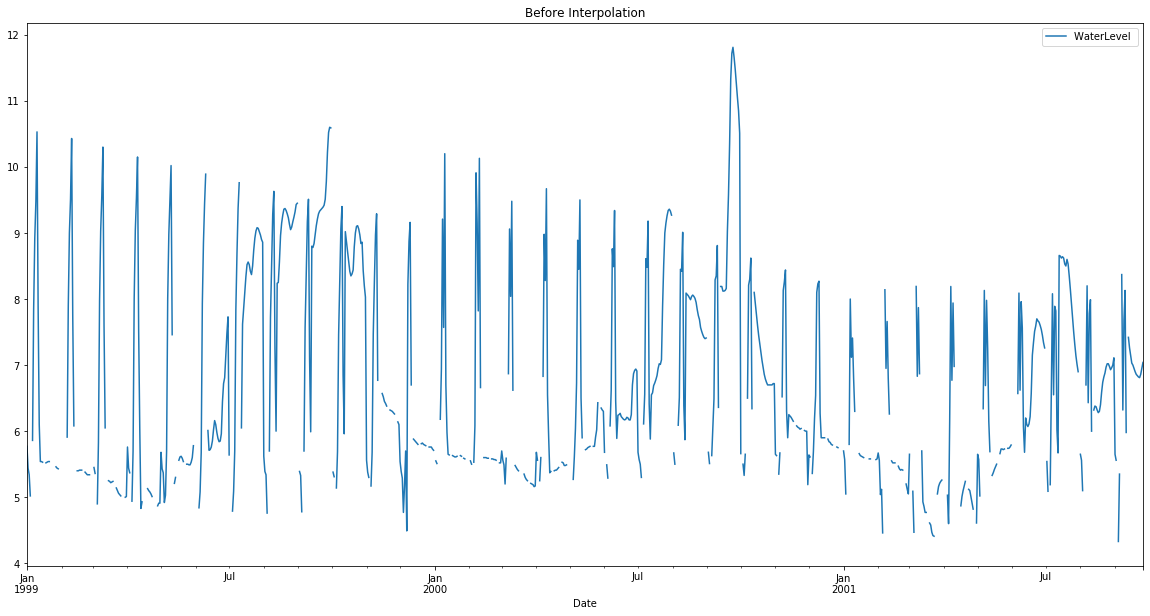

In [12]:
df.iloc[:1000].plot(figsize=(20,10),title="Before Interpolation")

In [20]:
#Imputing missing values using Linear Interpolation
df=df.interpolate(method='linear')
df=df.round(2)

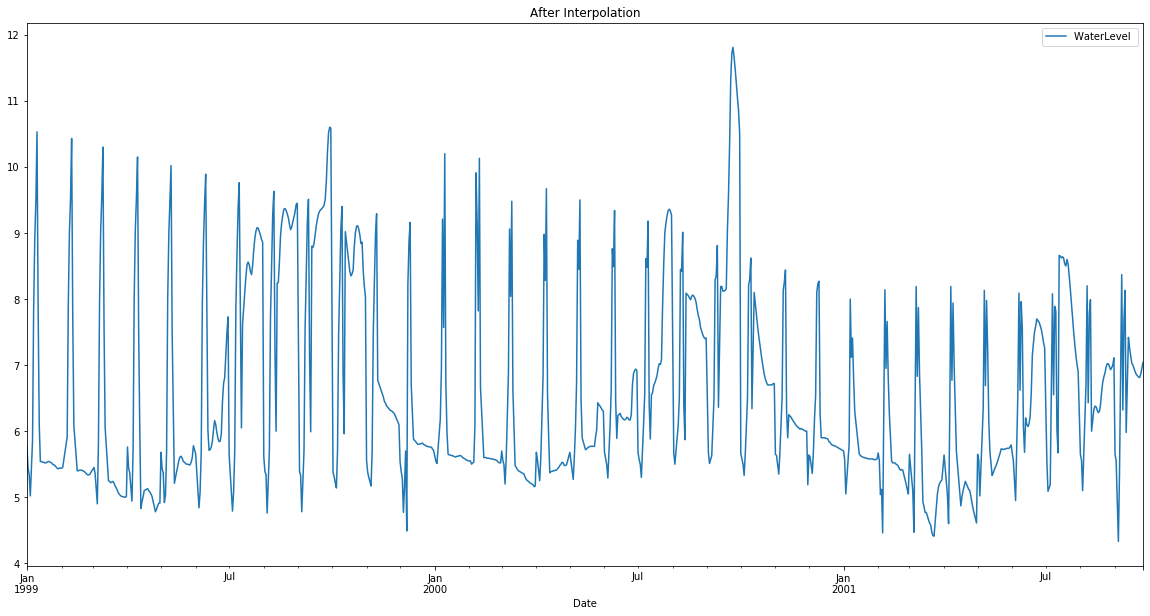

In [21]:
df.iloc[:1000].plot(figsize=(20,10),title="After Interpolation")

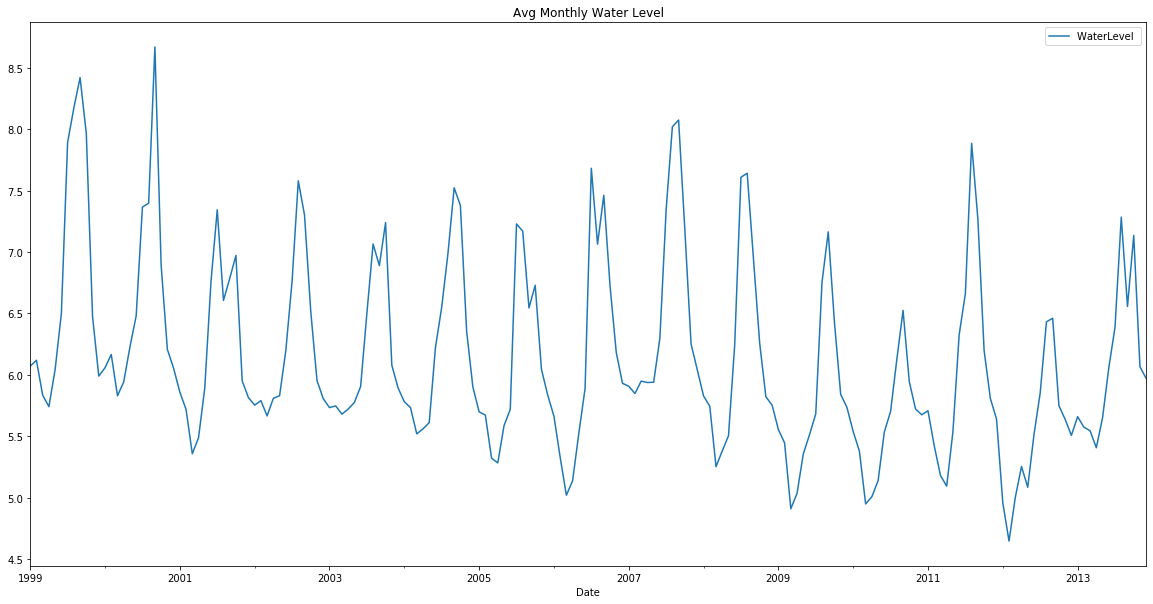

In [23]:
df2=df.resample('M').mean()
df2.plot(title="Avg Monthly Water Level",figsize=(20,10))

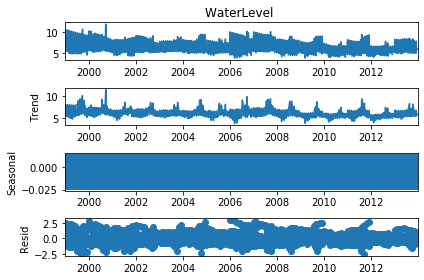

In [24]:
#ETS Decompsition (ADD)
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df["WaterLevel "], model='add')  # model='mul' also works
result.plot();

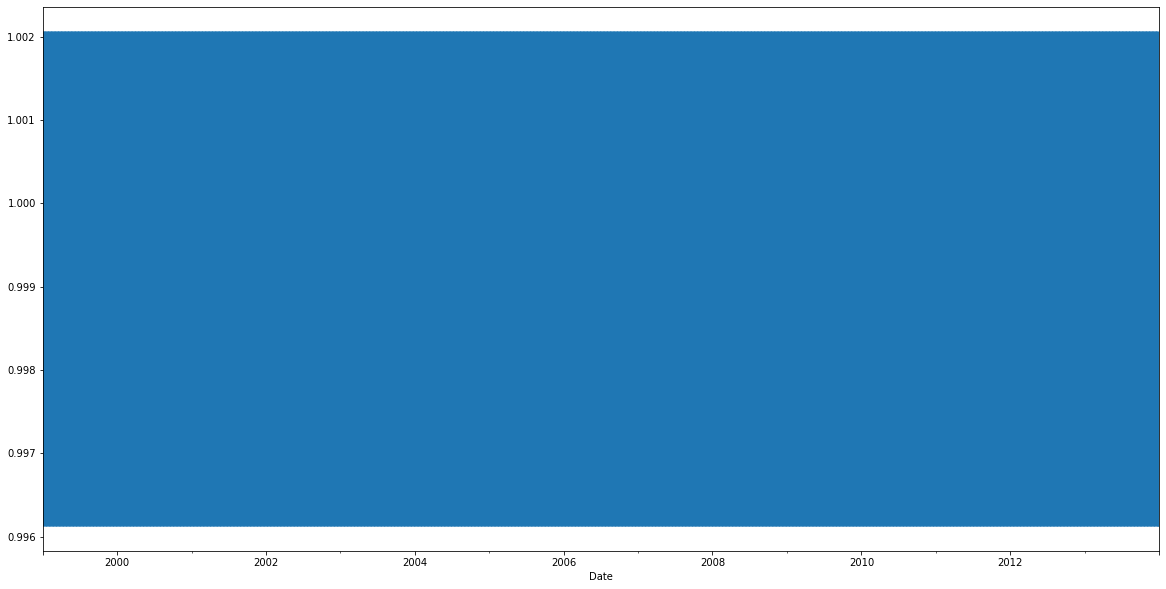

In [26]:
result.seasonal.plot(figsize=(20,10))

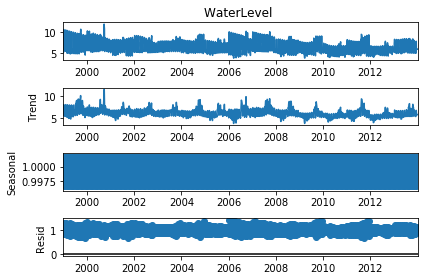

In [25]:
#ETS Decompsition (MUL)
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df["WaterLevel "], model='mul')  # model='mul' also works
result.plot();

In [ ]:
#Normalizing the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df["scaled_values"]=scaler.fit_transform(df)

In [ ]:
df.head()

Train Test Split

In [ ]:
train=df["scaled_values"].iloc[:4749]
test=df["scaled_values"].iloc[4749:]

In [ ]:
train.head()

## Forecasting with the Holt-Winters Method


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

fitted_model = ExponentialSmoothing(train,trend='add',seasonal='add',seasonal_periods=365).fit()

In [ ]:
test_predictions = fitted_model.forecast(730).rename('HW Forecast')

In [ ]:
test_predictions

In [ ]:
test.plot(legend=True,label='TEST',figsize=(12,8))
test_predictions.plot(legend=True,label='PREDICTION');

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
mean_absolute_error(test,test_predictions)

In [ ]:
mean_squared_error(test,test_predictions)

In [ ]:
np.sqrt(mean_squared_error(test,test_predictions))

In [ ]:
test.describe()